<img src='../_images/logos/Plotly-logo.png' width="200px">

# Plotly - Topic 03 - Plots: Part 02

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%202%20-%20Unit%20Objective.png"> 

## Topic Objectives

* Learn about and create bar plots, scatter plots, 3D scatter plot and parallel plots in Plotly.


---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%204%20-%20Import%20Package%20for%20Learning.png"> 

## Import Packages for Learning

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

## Plotly Plots: Part 02

In this topic, we will explore and learn multiple use cases in Plotly to deliver:
* Bar plot
* Scatter plot
* Scatter plot 3D
* Scatter Matrix 
* Parallel plots

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Bar Plot

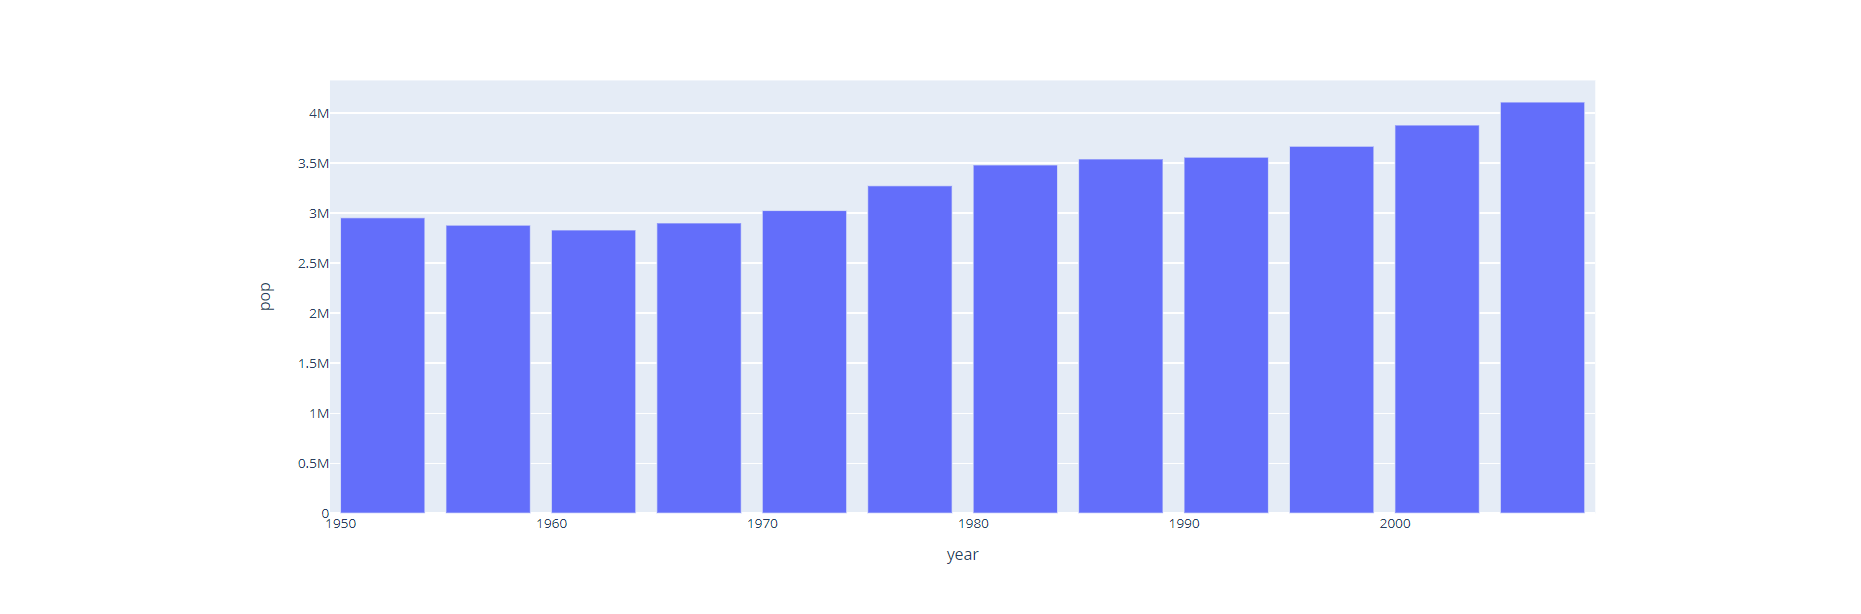

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

We are already familiar with what information a bar plot provides.

* Consider the ``gapminder`` dataset; it has the population, Gross Domestic Product, and life expectancy records for more than 140 countries. Each row represents a country for a given year
* We are querying data for Ireland

In [2]:
df = px.data.gapminder().query("country == 'Ireland'")
df.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
744,Ireland,Europe,1952,66.91,2952156,5210.280328,IRL,372
745,Ireland,Europe,1957,68.90,2878220,5599.077872,IRL,372
746,Ireland,Europe,1962,70.29,2830000,6631.597314,IRL,372
747,Ireland,Europe,1967,71.08,2900100,7655.568963,IRL,372
748,Ireland,Europe,1972,71.28,3024400,9530.772896,IRL,372


We want to plot population levels over the years. We use `px.bar()`, its documentation is [here](https://plotly.com/python-api-reference/generated/plotly.express.bar). The arguments are: 
* ``data_frame``
* ``x`` the groups you are interested in
* ``y`` the counts you want to display

Can you see any trend (upwards or downwards)?

In [3]:
fig = px.bar(df, x='year', y='pop')
fig.show()

Consider sales dataset, it shows records for 45 stores located in different regions - each store contains a number of departments.
* as datasaet contains more than 400 000 rows, let's check first 3 department from first 3 stores for the first week only.

In [4]:
df = pd.read_csv('data/sales_data-set.csv').query("Store < 4 & Dept < 4 & Date == '2010-05-02'")
df = df.astype({'Store':'object','Dept':'object'})
df

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-05-02,24924.50,False
7,1,2,2010-05-02,50605.27,False
14,1,3,2010-05-02,13740.12,False
500,2,1,2010-05-02,35034.06,False
507,2,2,2010-05-02,74661.16,False
514,2,3,2010-05-02,16873.20,False
998,3,1,2010-05-02,6453.58,False
1005,3,2,2010-05-02,17566.72,False
1012,3,3,2010-05-02,4710.29,False


We want to check each store's sales in different departments.
* We use ``px.bar()``, where the axis ``x`` holds the store, ``y`` is the weekly sales, and the departments colours the bar.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Note that the data considered here is like a "summary" since it sum up sales per department per store. You don't have repeated rows for the same combination of variables.

In [5]:
fig = px.bar(df, x="Store", y="Weekly_Sales", color="Dept", title="Store Sales")
fig.show()

---

Now consider the tips dataset. It holds records for waiter tips based on the day of the week, day time, total bill, gender, if it is a smoker table or not, and how many people were at the table.

In [6]:
df = px.data.tips()
df = df.sample(n=50, random_state=1)
df.head(3)

,total_bill,tip,sex,smoker,day,time,size
67,3.07,1.00,Female,Yes,Sat,Dinner,1
243,18.78,3.00,Female,No,Thur,Dinner,2
206,26.59,3.41,Male,Yes,Sat,Dinner,3


We want to know how many Females and Males we have in the dataset. We use `px.bar()` and set x='sex'. 
* Note that several rows share the same value of x (in this case, `sex` variable: female or male). The rectangles are stacked on top of one another by default.

In [7]:
fig = px.bar(df, x="sex")
fig.show()

If you prefer, you could process the data before plotting, in this case, with `.value_counts()` since you are using only one variable. Once you do a value count, you transform it to a DataFrame with `.to_frame()`

In [8]:
df_processed = df['sex'].value_counts().to_frame()
df_processed

,count
sex,
Male,28
Female,22


We plot the DataFrame above with `px.bar()`

In [9]:
fig = px.bar(data_frame=df_processed, y="count")
fig.show()

In both previous cases, you count how many females and males you have in the dataset.
* However, you may be interested in counting the levels of `tip` (numerical variable) per `sex`. You can add the argument `y` and set it to `tip`

In [10]:
fig = px.bar(df, x="sex", y='tip')
fig.show()

If you prefer, you could process the data before plotting, in this case, with `groupby()` and aggregate by `.sum()` and `.reset_index()` since you have two variables

In [11]:
df_processed = df[['sex','tip']].groupby('sex').sum().reset_index()
df_processed

,sex,tip
0,Female,64.62
1,Male,95.66


You may plot using the processed data frame
* Note the mini-stacked data is not present anymore

In [12]:
fig = px.bar(data_frame=df_processed, x="sex", y='tip')
fig.show()

You may be interested in colouring your bar plot with another categorical variable. You can do that with the ``color`` argument
* The ``barmode`` allows you to stack them (`stack`) or leave them side by side (`group`)

In [13]:
fig = px.bar(df, x="sex",  color="smoker", barmode="stack")
fig.show()

The example below has the same code from the previous cell but uses `barmode='group'`

In [14]:
fig = px.bar(df, x="sex", color="smoker", barmode="group")
fig.show()

---

As usual, you can facet your plot using face_row and facet_col.
* In this plot, you want to see multiple bar plots displaying the count of Females and Males, per day, per time and smoker status

In [15]:
fig = px.bar(data_frame=df, x="sex", color="smoker", barmode="group",
             facet_row="time", facet_col="day")
fig.show()

You will notice the days of the week are not ordered conventionally.
* You can manually arrange the order for your categorical variables in your plot with ``category_orders``; just parse a dictionary, where the ``key`` is the variable name, and the ``values`` are in the order you want.

In [16]:
fig = px.bar(data_frame=df, x="sex", color="smoker", barmode="group",
             facet_row="time", facet_col="day",
             category_orders={"day": ["Thur", "Fri", "Sat", "Sun"], "time": ["Lunch", "Dinner"]})
fig.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: We will use the DataFrame below, which uses the store sales dataset.
* Let's check first 3 department from first 3 stores as before, but for all weeks.

In [17]:
df_practice = pd.read_csv('data/sales_data-set.csv').query("Store < 4 & Dept < 4")
df_practice = df_practice.astype({'Store':'object','Dept':'object'})
df_practice.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-05-02,24924.50,False
1,1,1,2010-05-03,21827.90,False
2,1,1,2010-05-14,18926.74,False
3,1,1,2010-05-21,14773.04,False
4,1,1,2010-05-28,15580.43,False


Feel free to try out your ideas or use the following suggestion.

You are interested in using a bar plot. You decide to learn the sales sum of each store coloured by week type (with holiday or without) in a stacked bar plot

In [18]:
# write your code here
fig = px.bar(data_frame=df_practice, x="Store", y="Weekly_Sales", color="IsHoliday", barmode="stack",
             title="Store Sales by Week Type")
fig.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Scatter Plot

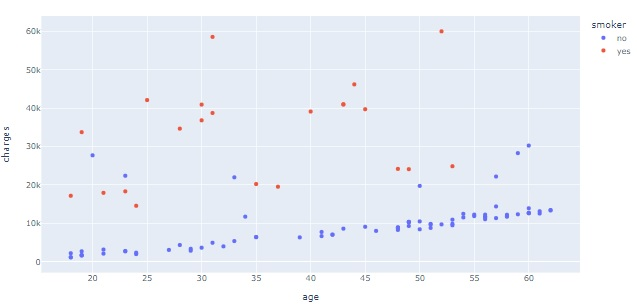

We are familiar with the Scatter plot. Consider the ``insurance`` dataset. It contains records of the relationship between personal attributes (age, gender, BMI: body mass index, family size, smoking habits), geographic factors, and their impact on medical insurance charges.

In [19]:
df = pd.read_csv("data/insurance.csv")
df = df.sample(n=100, random_state=1)
df.head()

,age,sex,bmi,children,smoker,region,charges
559,19,male,35.53,0,no,northwest,1646.4297
1087,57,male,31.54,0,no,northwest,11353.2276
1020,51,male,37.00,0,no,southwest,8798.5930
460,49,female,36.63,3,no,southeast,10381.4787
802,21,male,22.30,1,no,southwest,2103.0800


We want to build a scatter plot where the x-axis has age, the y-axis charges and is coloured by smoker. We use `px.scatter()`, its documentation is [here](https://plotly.com/python-api-reference/generated/plotly.express.scatter). 

In [20]:
fig = px.scatter(df, x="age", y="charges", color="smoker")
fig.show()

You can add Marginal Histograms to your Scatter Plot, by adding  marginal_y="box", and marginal_x="box"
* In this case, it gives quick insights into median, Q1, and Q3 outliers for each smoker type on charges and age

In [21]:
fig = px.scatter(df, x="age", y="charges", color="smoker",
                 marginal_y="box", marginal_x="box")
fig.show()

You can add a trend line. The trend line's benefit is seeing overall behaviour, like variance, range, min and max, and change rate.
* You just need to add `trendline='ols'` for a linear trend line. Other trend line options are found in the documentation

In [22]:
fig = px.scatter(df, x="age", y="charges", color="smoker",
                 trendline="ols")
fig.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: We will use the DataFrame below, which uses the features dataset. It contains data related to the store, and regional activity for the given dates.
* We selected only first 2 stores.

In [23]:
df_practice = pd.read_csv("data/Features_data_set.csv").query("Store < 3")
df_practice['Store'] = df_practice['Store'].astype('object')
df_practice['Date'] = pd.to_datetime(df_practice['Date'].str[-4:] + '-' + df_practice['Date'].str[3:5] + '-' + df_practice['Date'].str[:2])
df_practice

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
359,2,2013-06-28,85.37,3.495,8638.45,2457.32,9.00,4713.20,9079.05,NaN,NaN,False
360,2,2013-07-05,79.48,3.422,11651.46,4984.50,2024.67,15196.91,2862.06,NaN,NaN,False
361,2,2013-07-12,85.41,3.400,7527.10,1244.78,84.18,2626.70,3881.66,NaN,NaN,False
362,2,2013-07-19,79.16,3.556,3313.12,723.52,94.85,1224.91,2471.69,NaN,NaN,False


Feel free to try out your ideas on a scatter plot with Plotly using what you just learned

In [24]:
# write your code here
fig = px.scatter(df_practice, x="Temperature", y="Fuel_Price", color="Store",
                 marginal_x="box", trendline="ols")
fig.show()

---

Consider the ``gapminder`` dataset. It has records on population, Gross Domestic Product, and life expectancy for more than 140 countries. Each row represents a country in a given year

In [25]:
df = px.data.gapminder().head(500)
print(df.shape)
df.head()

(500, 8)


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


You can transform your scatter plot to a bubble chart and add  Animation
* When you set the argument `size`, you create a bubble chart, where each data point has its size related to a variable. In this case, we will use population
* Use the argument `animation_frame` to assign marks to animation frames. In this case, we animate over the years
* X and Y axis will GDP per capita and life expectancy
* The data points will be coloured by continent, and we will see the related country when we hover over them.

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Look how much information we can display in a single plot!
* n this case, we have three numerical variables (for x, y and size) and three categorical variables (year, continent and country) that allow for that

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png"> 

Note there is a play button; click to run the animation. There is also a stop button

In [26]:
fig = px.scatter(df, x="gdpPercap", y="lifeExp", 
                 animation_frame="year", 
                 size="pop",
                 color="continent", hover_name="country",
            )

fig.show()

You might feel it is nice to see the bubbles moving around, but you can't make much sense of it. We need to set additional parameters
* The issues rely on the sizes and their positions on the plot.
* We set `size_max=55`, so we get bigger circles (there is no rule for 55, it is trial and error)
* The ``x-axis`` has a wide range; we can compare levels better over a large range of values when it is in log scale, so we add `log_x=True`
* We set in a list [min, max] the x and y range limits with range_x and range_y. You will find a suitable number for min and max using trial and error 


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%209-%20Well%20done.png"> Now it is clear to see how continents changed their GDP per capita, life expectancy, and population levels over time.

In [27]:
fig = px.scatter(df, x="gdpPercap", y="lifeExp", 
                 animation_frame="year", 
                 size="pop",size_max=55, 
                 color="continent", hover_name="country",
                 log_x=True, range_x=[100,100000], range_y=[25,90]
            )

fig.show()

Again, you can facet your plot if you wish to view individualised animated scatter plots.
* This visualisation is, in fact, very powerful. Reflect for a moment on the meaning of it when you consider the GDP per capita level, life expectancy and population across different countries. How similar and different are the patterns among them?

In [28]:
fig = px.scatter(df, x="gdpPercap", y="lifeExp", animation_frame="year",
           size="pop", color="continent", hover_name="country", facet_col="continent",
           log_x=True, size_max=30, range_x=[100,100000], range_y=[25,90])
fig.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png">  

### Animation Side Note

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png">  

You can animate almost all the plots we are presenting in this lesson: histograms, boxplots, bar plots, scatter plots, maps etc. However, it requires having your data in good shape when adding animation. To validate, look for the ``animation_frame`` argument in the studied functions.




<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%207-%20Note.png">

Typically you will be interested in animating your data when:
  * There is a time/date component, like the year, month, day, weekday etc.
  * Or, when you have a categorical variable, you are interested in checking the behaviour across its levels dynamically and animatedly.

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Scatter Plot 3D

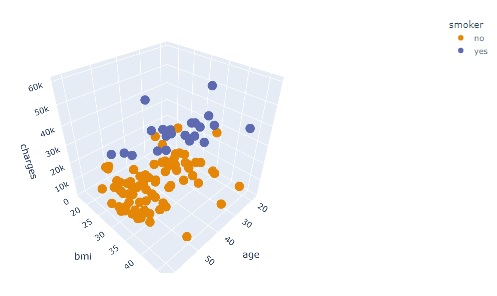

Consider the insurance dataset
* It has records on the relationship between personal attributes (age, gender, BMI: body mass index, family size, smoking habits), geographic factors, and their impact on medical insurance charges.

In [29]:
df = pd.read_csv("data/insurance.csv")
df = df.sample(n=100, random_state=1)
df.head()

,age,sex,bmi,children,smoker,region,charges
559,19,male,35.53,0,no,northwest,1646.4297
1087,57,male,31.54,0,no,northwest,11353.2276
1020,51,male,37.00,0,no,southwest,8798.5930
460,49,female,36.63,3,no,southeast,10381.4787
802,21,male,22.30,1,no,southwest,2103.0800


We are interested in creating a 3D scatter plot.


Notice that the colour variable is categorical in this example. That will create a discrete colour sequence
* As we studied in a previous notebook, the colour aspect can be managed with the `color_discrete_sequence` argument. You can check the possible arguments with the command `px.colors.qualitative.swatches()`

In [30]:
px.colors.qualitative.swatches()

We create a 3D scatter plot with px.scatter_3d(). The documentation is found [here](https://plotly.com/python-api-reference/generated/plotly.express.scatter_3d.html). The arguments are x, y and z for the axis coordinates, colour to set the colour for data points. color_discrete_sequence defines the colour palette.

In [31]:
fig = px.scatter_3d(df, x="age", y="bmi", z="charges",
                    color='smoker',
                    color_discrete_sequence=px.colors.qualitative.Vivid)
fig.show()

---

Consider UK MacroData dataset now
* It contains records of quarterly GDP, CPI, Bank Rates and Investments for 2000 - 2023 period.

In [32]:
df = pd.read_csv("data/UK_MacroData.csv")
df.head()

,Date,GDP (£ m),CPI,Bank Rate,Gross Fixed Capital Formation (Investments)
0,2000 Q1,401242,1.1,5.875,69114.0
1,2000 Q2,404196,1.0,6.000,73074.0
2,2000 Q3,406795,1.2,6.000,68011.0
3,2000 Q4,409411,1.4,6.000,70115.0
4,2001 Q1,413054,1.3,5.750,70186.0


The use case now is different; we will use a continuous variable to colour the plot: ``Bank Rate``


That will create a scale with a range of colours. You can set the colours with the `color_continuous_scale` argument 
* The options for this argument can be found with the command: `px.colors.sequential.swatches() `

In [33]:
px.colors.sequential.swatches()

We picked 'ice'


In [34]:
fig = px.scatter_3d(df, x='Gross Fixed Capital Formation (Investments)', y='CPI', z='GDP (£ m)',
                    color='Bank Rate',color_continuous_scale='ice')
fig.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**:  Do a 3D Scatter plot using the Car Price dataset using three numerical variables and colour by fuel type.

In [35]:
df_practice = pd.read_csv("data/CarPrice_Assignment.csv")
df_practice.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


Task: Can you see patterns among the variables to see regions that are more typical from a given class? Also, is there a region where the classes are mixed/mingled?

In [36]:
# write your code here
fig = px.scatter_3d(df_practice, x='carlength', y='carwidth', z='carheight',
                    color='price',color_continuous_scale='ice')
fig.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Scatter Matrix

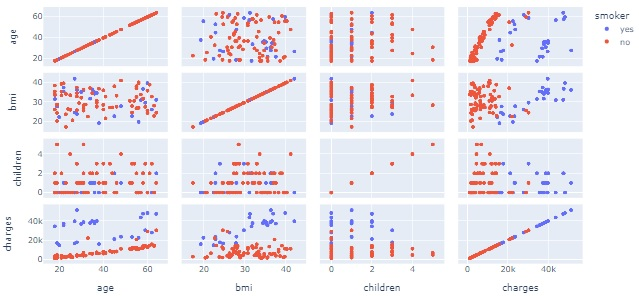

 Similar to Pairplot from Seaborn, we can use a Scatter matrix in Plotly with `px.scatter_matrix()`; its documentation is [here](https://plotly.github.io/plotly.py-docs/generated/plotly.express.scatter_matrix.html). For a basic plot, we have to provide the following arguments: data_frame for the data, dimensions for the columns you want to plot, and colour so you distinguish the dots visually in the plot.
 * One downside is that this figure shows repeated information since the upper triangle has the same information as the lower triangle
 * An upside is that we can interactively select data points in a given plot (for example, select a few data points on charges x bmi plot), and the same data points will be highlighted on the other plots.

In [37]:
df = pd.read_csv("data/insurance.csv").head(100)
fig = px.scatter_matrix(data_frame=df,
                        dimensions=["age", "bmi", "children", "charges"],
                        color="smoker",
                        )
fig.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: We will use the DataFrame below, which uses the insurance dataset.

In [38]:
df_practice = pd.read_csv("data/insurance.csv")
df_practice = df_practice.sample(n=100, random_state=1)
df_practice.head()

,age,sex,bmi,children,smoker,region,charges
559,19,male,35.53,0,no,northwest,1646.4297
1087,57,male,31.54,0,no,northwest,11353.2276
1020,51,male,37.00,0,no,southwest,8798.5930
460,49,female,36.63,3,no,southeast,10381.4787
802,21,male,22.30,1,no,southwest,2103.0800


You are interested in using a pair plot. You decide on doing multiple plots, using colour as other categorical variables (region and sex) 

In [39]:
# write your code here
fig = px.scatter_matrix(data_frame=df_practice,
                        dimensions=["age", "bmi", "children", "charges"],
                        color="region",)
fig.show()

In [40]:
# write your code here
fig = px.scatter_matrix(data_frame=df_practice,
                        dimensions=["age", "bmi", "children", "charges"],
                        color="sex",)
fig.show()

---

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%2010-%20Lesson%20Content.png"> 

### Parallel Plots

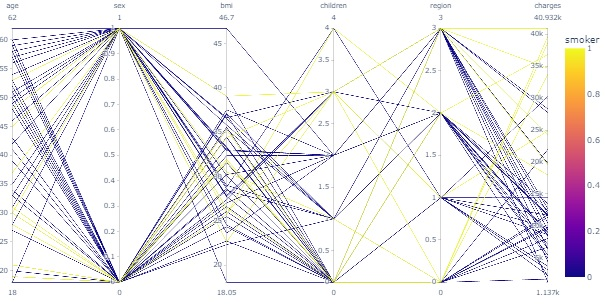

* In a Parallel Coordinates plot, each observation of the DataFrame is a polyline mark which goes through a set of parallel axes, where each axes is a **numerical variable**
* It is useful when you are interested in revealing patterns of the relationships between numerical variables.

Consider the insurance dataset
* It has records on the relationship between personal attributes (age, gender, BMI: body mass index, family size, smoking habits), geographic factors, and their impact on medical insurance charges.

In [41]:
df = pd.read_csv("data/insurance.csv")
df = df.sample(n=50, random_state=1)
df.head(3)

,age,sex,bmi,children,smoker,region,charges
559,19,male,35.53,0,no,northwest,1646.4297
1087,57,male,31.54,0,no,northwest,11353.2276
1020,51,male,37.00,0,no,southwest,8798.5930


We convert categorical to numerical with `.map()`
* You should know in advance the category levels you want to replace; for example, sex has female and male, smoker has no, and yes.

In [42]:
df['smoker'] = df['smoker'].map({'no':0, 'yes':1}).astype('int')
df['sex'] = df['sex'].map({'male':0, 'female':1}).astype('int')
df['region']= df['region'].map({'northwest':0, 'northeast':1, 'southwest':2, 'southeast':3}).astype('int')
df.head(3)

,age,sex,bmi,children,smoker,region,charges
559,19,0,35.53,0,0,0,1646.4297
1087,57,0,31.54,0,0,0,11353.2276
1020,51,0,37.00,0,0,2,8798.5930


We use `px.parallel_coordinates()`, its documentation is [here](https://plotly.com/python-api-reference/generated/plotly.express.parallel_coordinates.html). We parse the dataset, the columns we want to see in the plot and colour.
* Note we parsed a list of the columns we want to see in the plot. We don't want to see 'smoker', since that will be the color.
* Note the plot is coloured by `smoker`, so we are interested to see patterns for smokers across the variables.
* Note higher levels for `charges` appear in records who smoke, and lower levels for `charges` happen more often in case of non-smokers.

In [43]:
fig = px.parallel_coordinates(df, color="smoker",
                              dimensions = ['age','sex','bmi',
                                            'children',	'region','charges'])
fig.show()

We coloured the plot by `smoker`, which is now a numerical variable. Check the potential colours style to use in this case

In [44]:
px.colors.sequential.swatches() 

We picked `'viridis'` for the colour

In [45]:
fig = px.parallel_coordinates(df, color="smoker",
                              dimensions = ['age','sex','bmi',
                                            'children',	'region','charges'],
                              color_continuous_scale='viridis')
fig.show()

---

If your data has more categorical variables or you are only interested in conducting an analysis with categorical variables, it may be more effective to use `px.parallel_categories()`, so you don't have to add the effort of converting from categorical to numerical. Its documentation is [here](https://plotly.com/python-api-reference/generated/plotly.express.parallel_categories.html)


<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%206%20-%20Warning.png"> 

The only aspect is that your **`color` variable should be numerical**. In case this variable is already a number, no additional steps are needed. In case it is a category, you will need to convert it
* In our exercise, we are using Bank Churners dataset, which consists of 10,000 customers mentioning their age, salary, marital_status, credit card limit, credit card category, etc.

In [46]:
df = pd.read_csv("data/BankChurners.csv").drop(['CLIENTNUM'],axis=1).sample(n=50, random_state=5)
df['Attrition_Flag'] = df['Attrition_Flag'].map({'Existing Customer':0, 'Attrited Customer':1}).astype('int')
print(df.shape)
df.head(3)

(50, 20)


,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
1646,0,36,F,3,Unknown,Married,Less than $40K,Blue,36,6,5,3,2786.0,1628,1158.0,1.314,2853,55,0.667,0.584
7880,0,42,M,2,Uneducated,Married,$60K - $80K,Blue,30,1,2,3,3086.0,0,3086.0,0.808,4129,81,0.884,0.000
7586,1,38,F,1,High School,Married,Less than $40K,Blue,28,3,3,3,4196.0,731,3465.0,0.485,1868,30,0.200,0.174


You will notice only categorical variables; all numerical are disconsidered
* This plot is useful since you can see the proportions on each variable's level (for example, there were more blue than silver cards, but no silver cards flagged as attrition.)
* Note we didn't parse dimensions, so we allowed the plot to include all possible variables, including survived (which is the colour variable). This is also fine. When you are not sure which variables to plot at first, you plot all, then refine.

In [47]:
fig = px.parallel_categories(df,dimensions=['Attrition_Flag','Gender','Gender', 'Dependent_count', 'Education_Level',
                                            'Marital_Status','Income_Category', 'Card_Category','Total_Relationship_Count', 
                                            'Months_Inactive_12_mon','Contacts_Count_12_mon'], 
                             color="Attrition_Flag", color_continuous_scale='viridis')
fig.show()

<img width="3%" height="3%" align="top"  src="https://codeinstitute.s3.amazonaws.com/predictive_analytics/jupyter_notebook_icons/Icon%205%20-%20Practice.png"> 

**PRACTICE**: We will use the DataFrame below, which uses the gapminder dataset.

In [48]:
df_practice = px.data.gapminder()
df_practice = df_practice.sample(n=100, random_state=1).reset_index(drop=True)
df_practice.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Indonesia,Asia,1952,37.468,82052000,749.681655,IDN,360
1,Sierra Leone,Africa,1997,39.897,4578212,574.648158,SLE,694
2,Equatorial Guinea,Africa,2007,51.579,551201,12154.089750,GNQ,226
3,India,Asia,1987,58.553,788000000,976.512676,IND,356
4,Rwanda,Africa,1962,43.000,3051242,597.473073,RWA,646


We map the continents to numbers

In [49]:
continent_map = {'Asia':0, 'Europe':1, 'Africa':2,'Americas':3, 'Oceania':4}
df_practice['continent'] = df_practice['continent'].map(continent_map)
df_practice.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Indonesia,0,1952,37.468,82052000,749.681655,IDN,360
1,Sierra Leone,2,1997,39.897,4578212,574.648158,SLE,694
2,Equatorial Guinea,2,2007,51.579,551201,12154.089750,GNQ,226
3,India,0,1987,58.553,788000000,976.512676,IND,356
4,Rwanda,2,1962,43.000,3051242,597.473073,RWA,646


 First, just a quick recap on the continent_map

In [50]:
continent_map

{'Asia': 0, 'Europe': 1, 'Africa': 2, 'Americas': 3, 'Oceania': 4}

Make a parallel coordinates with dimensions as ['continent','lifeExp',	'pop',	'gdpPercap' ] ,colored by continent.
* What are the patterns that you see? Where typically do we have a larger population, life expectancy or GDP per cap?

In [51]:
# write code here
fig = px.parallel_categories(df_practice,dimensions=['continent','lifeExp','pop', 'gdpPercap'], 
                             color="continent", color_continuous_scale='viridis')               
fig.show()